# 03 · Fixed-Effects Regressions

Does a higher minimum wage move unemployment, poverty, or median household
income once state and year fixed effects are controlled for?

Three separate panel regressions, one per outcome, same independent variable
(effective minimum wage). State fixed effects absorb anything constant within a
state (industry mix, cost of living); year fixed effects absorb national shocks
hitting every state at once (recessions, federal policy). Standard errors are
clustered by state.

$$y_{st} = \beta \cdot \text{MinWage}_{st} + \alpha_s + \gamma_t + \varepsilon_{st}$$

| | |
|---|---|
| **Input** | `data/processed/state_panel_1995_2024.csv` |
| **Output** | `figures/04_regression_results.png` |

**Contents**
1. Unemployment
2. Poverty rate
3. Median household income
4. Results summary

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS

from style import *

apply_style()

In [2]:
panel = pd.read_csv('../data/processed/state_panel_1995_2024.csv')
panel = panel.set_index(['state', 'year'])

## 1. Unemployment

In [3]:
model = PanelOLS.from_formula(
    'pct_unemployed ~ effective_min_wage + EntityEffects + TimeEffects',
    data=panel
)

results = model.fit(cov_type='clustered', cluster_entity=True)
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:         pct_unemployed   R-squared:                        0.0018
Estimator:                   PanelOLS   R-squared (Between):              0.0946
No. Observations:                1500   R-squared (Within):              -0.0054
Date:                Sat, Oct 03 2026   R-squared (Overall):              0.0853
Time:                        17:41:41   Log-likelihood                   -1784.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.5604
Entities:                          50   P-value                           0.1098
Avg Obs:                       30.000   Distribution:                  F(1,1420)
Min Obs:                       30.000                                           
Max Obs:                       30.000   F-statistic (robust):             1.0228
                            

**Result:** coefficient 0.036, p = 0.31. No statistically significant
relationship between minimum wage and unemployment.

## 2. Poverty Rate

In [4]:
model_poverty = PanelOLS.from_formula(
    'pct_poverty ~ effective_min_wage + EntityEffects + TimeEffects',
    data=panel
)
results_poverty = model_poverty.fit(cov_type='clustered', cluster_entity=True)
print(results_poverty)

                          PanelOLS Estimation Summary                           
Dep. Variable:            pct_poverty   R-squared:                        0.0008
Estimator:                   PanelOLS   R-squared (Between):              0.0263
No. Observations:                1500   R-squared (Within):               0.0067
Date:                Sat, Oct 03 2026   R-squared (Overall):              0.0260
Time:                        17:41:42   Log-likelihood                   -1824.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.1850
Entities:                          50   P-value                           0.2765
Avg Obs:                       30.000   Distribution:                  F(1,1420)
Min Obs:                       30.000                                           
Max Obs:                       30.000   F-statistic (robust):             0.1595
                            

**Result:** coefficient 0.025, p = 0.69. No statistically significant
relationship between minimum wage and poverty.

## 3. Median Household Income

In [5]:
model_income = PanelOLS.from_formula(
    'median_income ~ effective_min_wage + EntityEffects + TimeEffects',
    data=panel
)
results_income = model_income.fit(cov_type='clustered', cluster_entity=True)
print(results_income)

                          PanelOLS Estimation Summary                           
Dep. Variable:          median_income   R-squared:                        0.1058
Estimator:                   PanelOLS   R-squared (Between):              0.3044
No. Observations:                1500   R-squared (Within):               0.2869
Date:                Sat, Oct 03 2026   R-squared (Overall):              0.3033
Time:                        17:41:42   Log-likelihood                -1.433e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      168.04
Entities:                          50   P-value                           0.0000
Avg Obs:                       30.000   Distribution:                  F(1,1420)
Min Obs:                       30.000                                           
Max Obs:                       30.000   F-statistic (robust):             15.527
                            

**Result:** coefficient 1,265.50, p = 0.0001. A $1 higher minimum wage is
associated with roughly $1,266 higher median household income - statistically
significant, but read as associative rather than causal.

## 4. Results Summary

In [6]:
fits = {
    'pct_unemployed': results,
    'pct_poverty': results_poverty,
    'median_income': results_income,
}

summary = pd.DataFrame([
    {
        'Outcome': VAR_LABELS[outcome],
        'Coefficient': res.params['effective_min_wage'],
        'Std. Error': res.std_errors['effective_min_wage'],
        'P-value': res.pvalues['effective_min_wage'],
        'CI lower': res.conf_int().loc['effective_min_wage', 'lower'],
        'CI upper': res.conf_int().loc['effective_min_wage', 'upper'],
    }
    for outcome, res in fits.items()
]).set_index('Outcome')
summary['Significant (5%)'] = summary['P-value'] < 0.05

summary.style.format({
    'Coefficient': '{:,.3f}', 'Std. Error': '{:,.3f}', 'P-value': '{:.4f}',
    'CI lower': '{:,.3f}', 'CI upper': '{:,.3f}',
})

,Coefficient,Std. Error,P-value,CI lower,CI upper,Significant (5%)
Outcome,,,,,,
Unemployment rate (%),0.036,0.036,0.3120,-0.034,0.107,False
Poverty rate (%),0.025,0.064,0.6897,-0.099,0.150,False
Median household income ($),"1,265.533",321.161,0.0001,635.531,"1,895.535",True


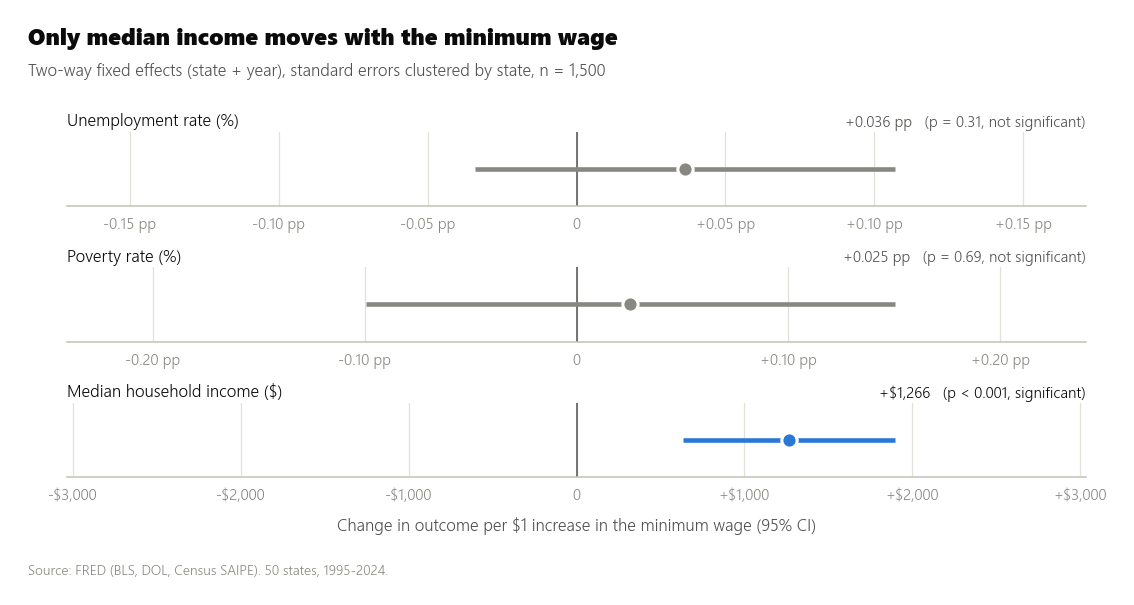

In [7]:
# Coefficient plot - one panel per outcome, since each is on its own scale
fig, axes = plt.subplots(3, 1, figsize=(10, 4.8), sharex=False)

for ax, (outcome, row) in zip(axes, summary.iterrows()):
    color = PRIMARY if row['Significant (5%)'] else INK_MUTED
    ax.axvline(0, color=INK_SECONDARY, linewidth=1, zorder=1)
    ax.hlines(0, row['CI lower'], row['CI upper'], color=color, linewidth=3, zorder=2)
    ax.plot(row['Coefficient'], 0, 'o', ms=10, color=color,
            markeredgecolor='white', markeredgewidth=2, zorder=3)

    # Symmetric x-range around zero so "no effect" sits in the same place on every panel
    reach = max(abs(row['CI lower']), abs(row['CI upper'])) * 1.6
    ax.set_xlim(-reach, reach)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=True)

    is_dollars = '$' in outcome
    fmt = (lambda v: f"{'+' if v >= 0 else '-'}${abs(v):,.0f}") if is_dollars else (lambda v: f"{v:+.2f} pp")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _, fmt=fmt: fmt(v) if v else '0'))

    verdict = 'significant' if row['Significant (5%)'] else 'not significant'
    p_text = 'p < 0.001' if row['P-value'] < 0.001 else f"p = {row['P-value']:.2f}"
    ax.set_title(f"{outcome}", fontsize=11, pad=4)
    ax.text(1.0, 1.02, f"{(f'{row['Coefficient']:+.3f} pp' if not is_dollars else fmt(row['Coefficient']))}   ({p_text}, {verdict})",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
            color=INK if row['Significant (5%)'] else INK_SECONDARY)

axes[-1].set_xlabel('Change in outcome per $1 increase in the minimum wage (95% CI)')
fig.tight_layout(h_pad=1.5)
fig.subplots_adjust(top=0.80)
titles(fig, 'Only median income moves with the minimum wage',
       'Two-way fixed effects (state + year), standard errors clustered by state, n = 1,500', legend=True)
source_note(fig)
save_fig(fig, '04_regression_results')
plt.show()

**Takeaways**

- **Unemployment:** no statistically significant relationship with minimum wage.
- **Poverty rate:** no statistically significant relationship with minimum wage.
- **Median household income:** a statistically significant positive relationship,
  read as associative rather than causal.

See the Limitations section of `output/Minimum_Wage_Policy_Brief.pdf` for what
this design can and cannot conclude.